In [104]:
import numpy as np
import matplotlib.pyplot as plt

input_folder = "simulations/X_design/scenario_3_22"

X = np.load(f"{input_folder}/X.npy")
n,d = X.shape
beta = np.load(f"{input_folder}/beta.npy")
ystar = np.load(f"{input_folder}/y_latent.npy")
l, u,  sigma_y_true = list(np.load(f"{input_folder}/l_u_sigma.npy"))
y = np.clip(ystar, l, u).copy()
beta_blocks = np.load(f"{input_folder}/beta_blocks.npy")

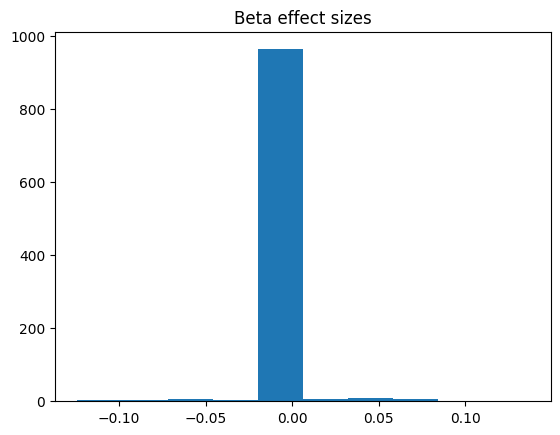

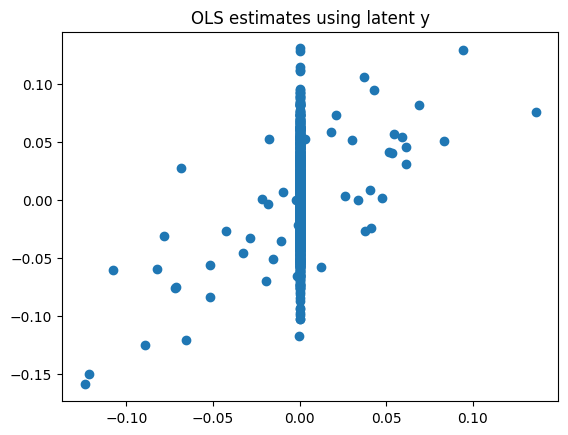

0.0015852809266936891


0.0033731190899836095

In [103]:
plt.hist(beta)
plt.title("Beta effect sizes")
plt.show()

beta_est = np.linalg.inv(X.T @ X) @ X.T @ ystar
plt.scatter(beta, beta_est)
plt.title("OLS estimates using latent y")
plt.show()

print(np.var(beta_est))

var_beta = np.var(beta[beta != 0])
var_beta

MFVI:   0%|          | 0/1000 [00:00<?, ?it/s]

Early stopping


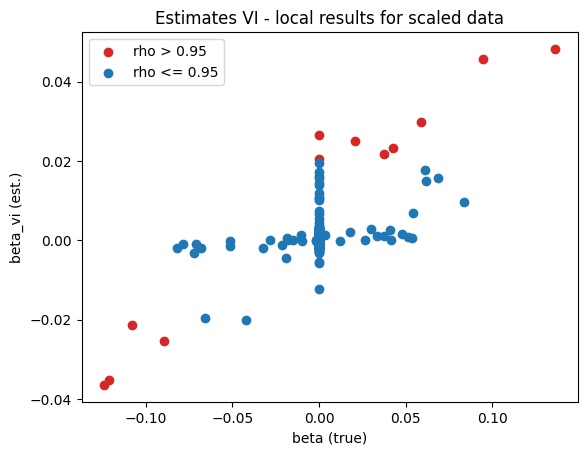

Confusion matrix:
 [[950   2]
 [ 39  10]]
Precision: 0.833  Recall: 0.204  MCC: 0.400


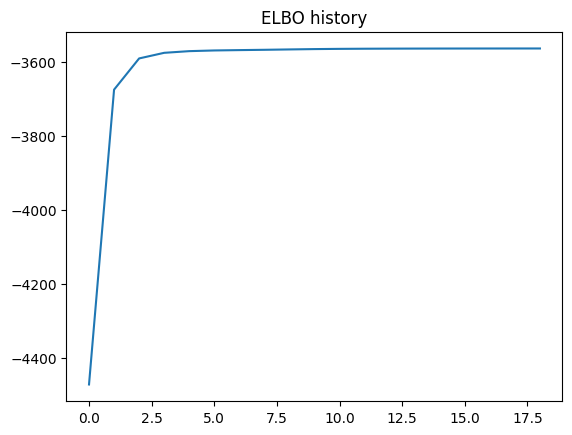

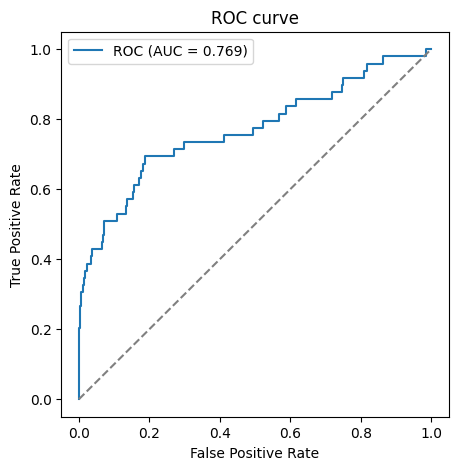

In [96]:
import aux_functions as aux_f
from mfvi_script import summary_orig
import mfvi_blocks_script
from importlib import reload
reload(mfvi_blocks_script)
from mfvi_blocks_script import SparseTobitStructuredVI

model_vi = SparseTobitStructuredVI(
    X, y,
    beta_blocks = beta_blocks,
    tau2= 0.001,
    pi0= 0.1, 
    seed= 22,
)

model_vi.fit(
    n_iter = 1000, 
    em = False,
    gamma_batch_size = 1,
)

summary = model_vi.summary()
summary["n_iters"] = len(model_vi.elbo_history)
summary = summary_orig(summary, mu_y, sd_y, 0)

pip_tr = 0.8
beta_vi = summary["m"]
mask = summary["rho"] > pip_tr

plt.scatter(beta[mask], beta_vi[mask], color="tab:red", label="rho > 0.95")
plt.scatter(beta[~mask], beta_vi[~mask], color="tab:blue", label="rho <= 0.95")
plt.title("Estimates VI - local results for scaled data")
plt.xlabel("beta (true)")
plt.ylabel("beta_vi (est.)")
plt.legend()
plt.show()

plt.plot(model_vi.elbo_history)
plt.title("ELBO history")

from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score,
    matthews_corrcoef, roc_curve, roc_auc_score
)

# Ground truth: nonzero true coefficients; predicted via PIP threshold at 0.5
y_true = (beta != 0).astype(int)
y_pred = (model_vi.rho > pip_tr).astype(int)

# Confusion matrix and metrics
cm = confusion_matrix(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
mcc = matthews_corrcoef(y_true, y_pred)

print("Confusion matrix:\n", cm)
print(f"Precision: {precision:.3f}  Recall: {recall:.3f}  MCC: {mcc:.3f}")

# ROC curve using rho as continuous score
fpr, tpr, _ = roc_curve(y_true, model_vi.rho)
auc = roc_auc_score(y_true, model_vi.rho)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"ROC (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve")
plt.legend()
plt.show()

In [92]:
import itertools
import numpy as np
import pandas as pd
from sklearn.metrics import matthews_corrcoef

# Ground truth for nonzero coefficients
y_true = (beta != 0).astype(int)

# Grid of candidate values (log-spaced, since tau2/pi0 span orders of magnitude)
tau2_grid = np.logspace(-5, -1, 9)   # 0.00001 ... 0.1, gęściej w małych wartościach
pi0_grid = np.linspace(0.02, 0.15, 8)  # zawężone wokół optimum

results = []
for tau2, pi0 in itertools.product(tau2_grid, pi0_grid):
    model = SparseTobitStructuredVI(
        X, y,
        beta_blocks=beta_blocks,
        tau2=tau2,
        pi0=pi0,
        seed=22,
    )
    model.fit(n_iter=1000, em=False, gamma_batch_size=1)

    y_pred = (model.rho > 0.5).astype(int)
    mcc = matthews_corrcoef(y_true, y_pred)
    results.append({"tau2": tau2, "pi0": pi0, "mcc": mcc})

df = pd.DataFrame(results).sort_values("mcc", ascending=False)
best = df.iloc[0]
print(f"Best: tau2={best.tau2:.4f}, pi0={best.pi0:.3f}, MCC={best.mcc:.3f}")
print(df.head(10))

Early stopping


MFVI:   0%|          | 0/1000 [00:00<?, ?it/s]

Early stopping


MFVI:   0%|          | 0/1000 [00:00<?, ?it/s]

Early stopping


...

Early stopping


MFVI:   0%|          | 0/1000 [00:00<?, ?it/s]

Early stopping


MFVI:   0%|          | 0/1000 [00:00<?, ?it/s]

Early stopping
Best: tau2=0.0010, pi0=0.094, MCC=0.431
        tau2       pi0       mcc
36  0.001000  0.094286  0.430836
42  0.003162  0.057143  0.422247
37  0.001000  0.112857  0.418442
35  0.001000  0.075714  0.414102
38  0.001000  0.131429  0.410779
41  0.003162  0.038571  0.406678
49  0.010000  0.038571  0.400440
34  0.001000  0.057143  0.400440
50  0.010000  0.057143  0.400188
43  0.003162  0.075714  0.399588


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plot_beta_with_block_summary(summary["m"], beta, beta_blocks, agg="sum")

MFVI:   0%|          | 0/1100 [00:00<?, ?it/s]

Early stopping


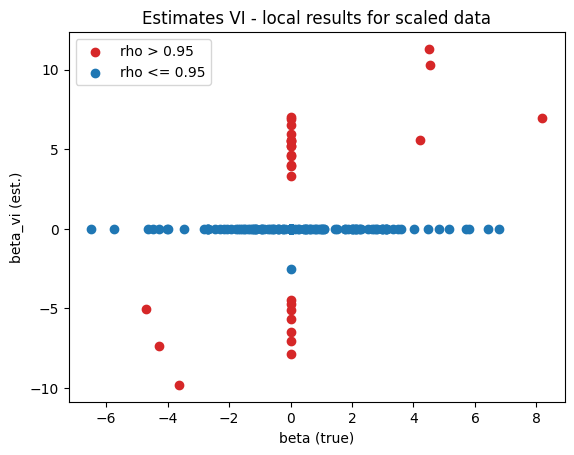

Text(0.5, 1.0, 'ELBO history')

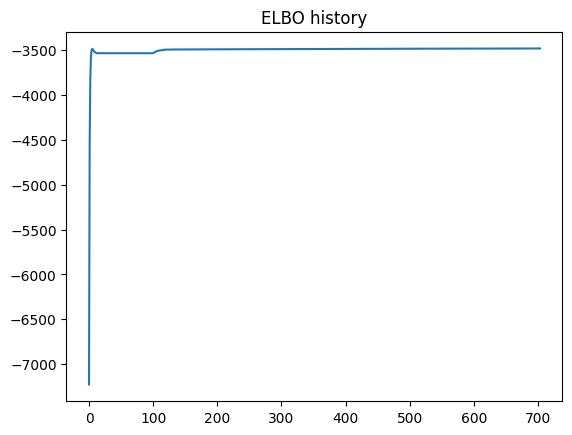

In [6]:
import aux_functions as aux_f
from mfvi_script import summary_orig
from mfvi_script import SparseTobitVI
    
y_scaled, sigma_y_scaled, l_scaled, u_scaled, mu_y, sd_y = aux_f.scale_y(y, l, u, sigma_y_true)


model_vi = SparseTobitVI(
    X, y_scaled,
    tau2= 1,
    pi0= 0.1, 
    seed= 22,
)

model_vi.fit(
    n_iter = 1000, 
    em_warmup = 100, 
    gamma_batch_size = 1,
    damping = 0.1
)

summary = model_vi.summary()
summary["n_iters"] = len(model_vi.elbo_history)
summary = summary_orig(summary, mu_y, sd_y, 0)

beta_vi = summary["m"]

mask = summary["rho"] > 0.95

plt.scatter(beta[mask], beta_vi[mask], color="tab:red", label="rho > 0.95")
plt.scatter(beta[~mask], beta_vi[~mask], color="tab:blue", label="rho <= 0.95")
plt.title("Estimates VI - local results for scaled data")
plt.xlabel("beta (true)")
plt.ylabel("beta_vi (est.)")
plt.legend()
plt.show()

plt.plot(model_vi.elbo_history)
plt.title("ELBO history")

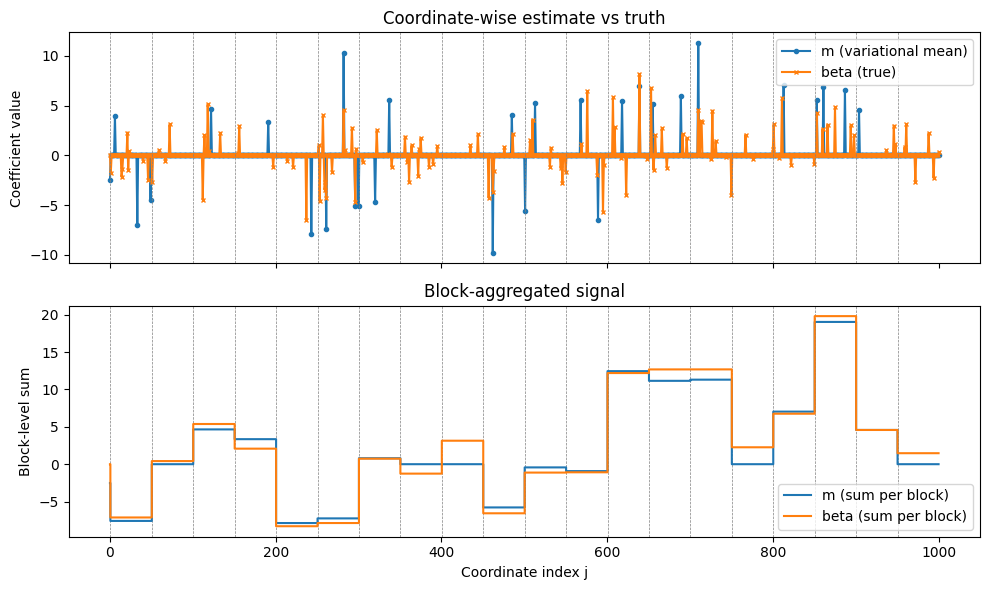

In [7]:
plot_beta_with_block_summary(summary["m"], beta, beta_blocks, agg="sum")